In [1]:
import pandas as pd
from powerball_ticket_generator import TemperatureLotteryGenerator
from powerball_backtester import PowerballBacktester
from jackpots_scraper import Jackpots

In [2]:
# Update Jackpots dataset
Jackpots().to_csv("jackpots.csv")

'jackpots.csv'

In [3]:
generator = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

tix = generator.generate_ticket_batch(
    n=5,
    max_T=200,
    include_metadata=False
)

tix = pd.DataFrame(tix)
tix

,white_1,white_2,white_3,white_4,white_5,red_ball
0,32,44,45,56,69,25
1,9,30,63,64,68,25
2,18,19,22,38,64,8
3,26,40,51,65,66,21
4,4,38,49,52,58,3



### 1) Baseline single-run backtest (fixed spend, multiplier on, temperatures stored)

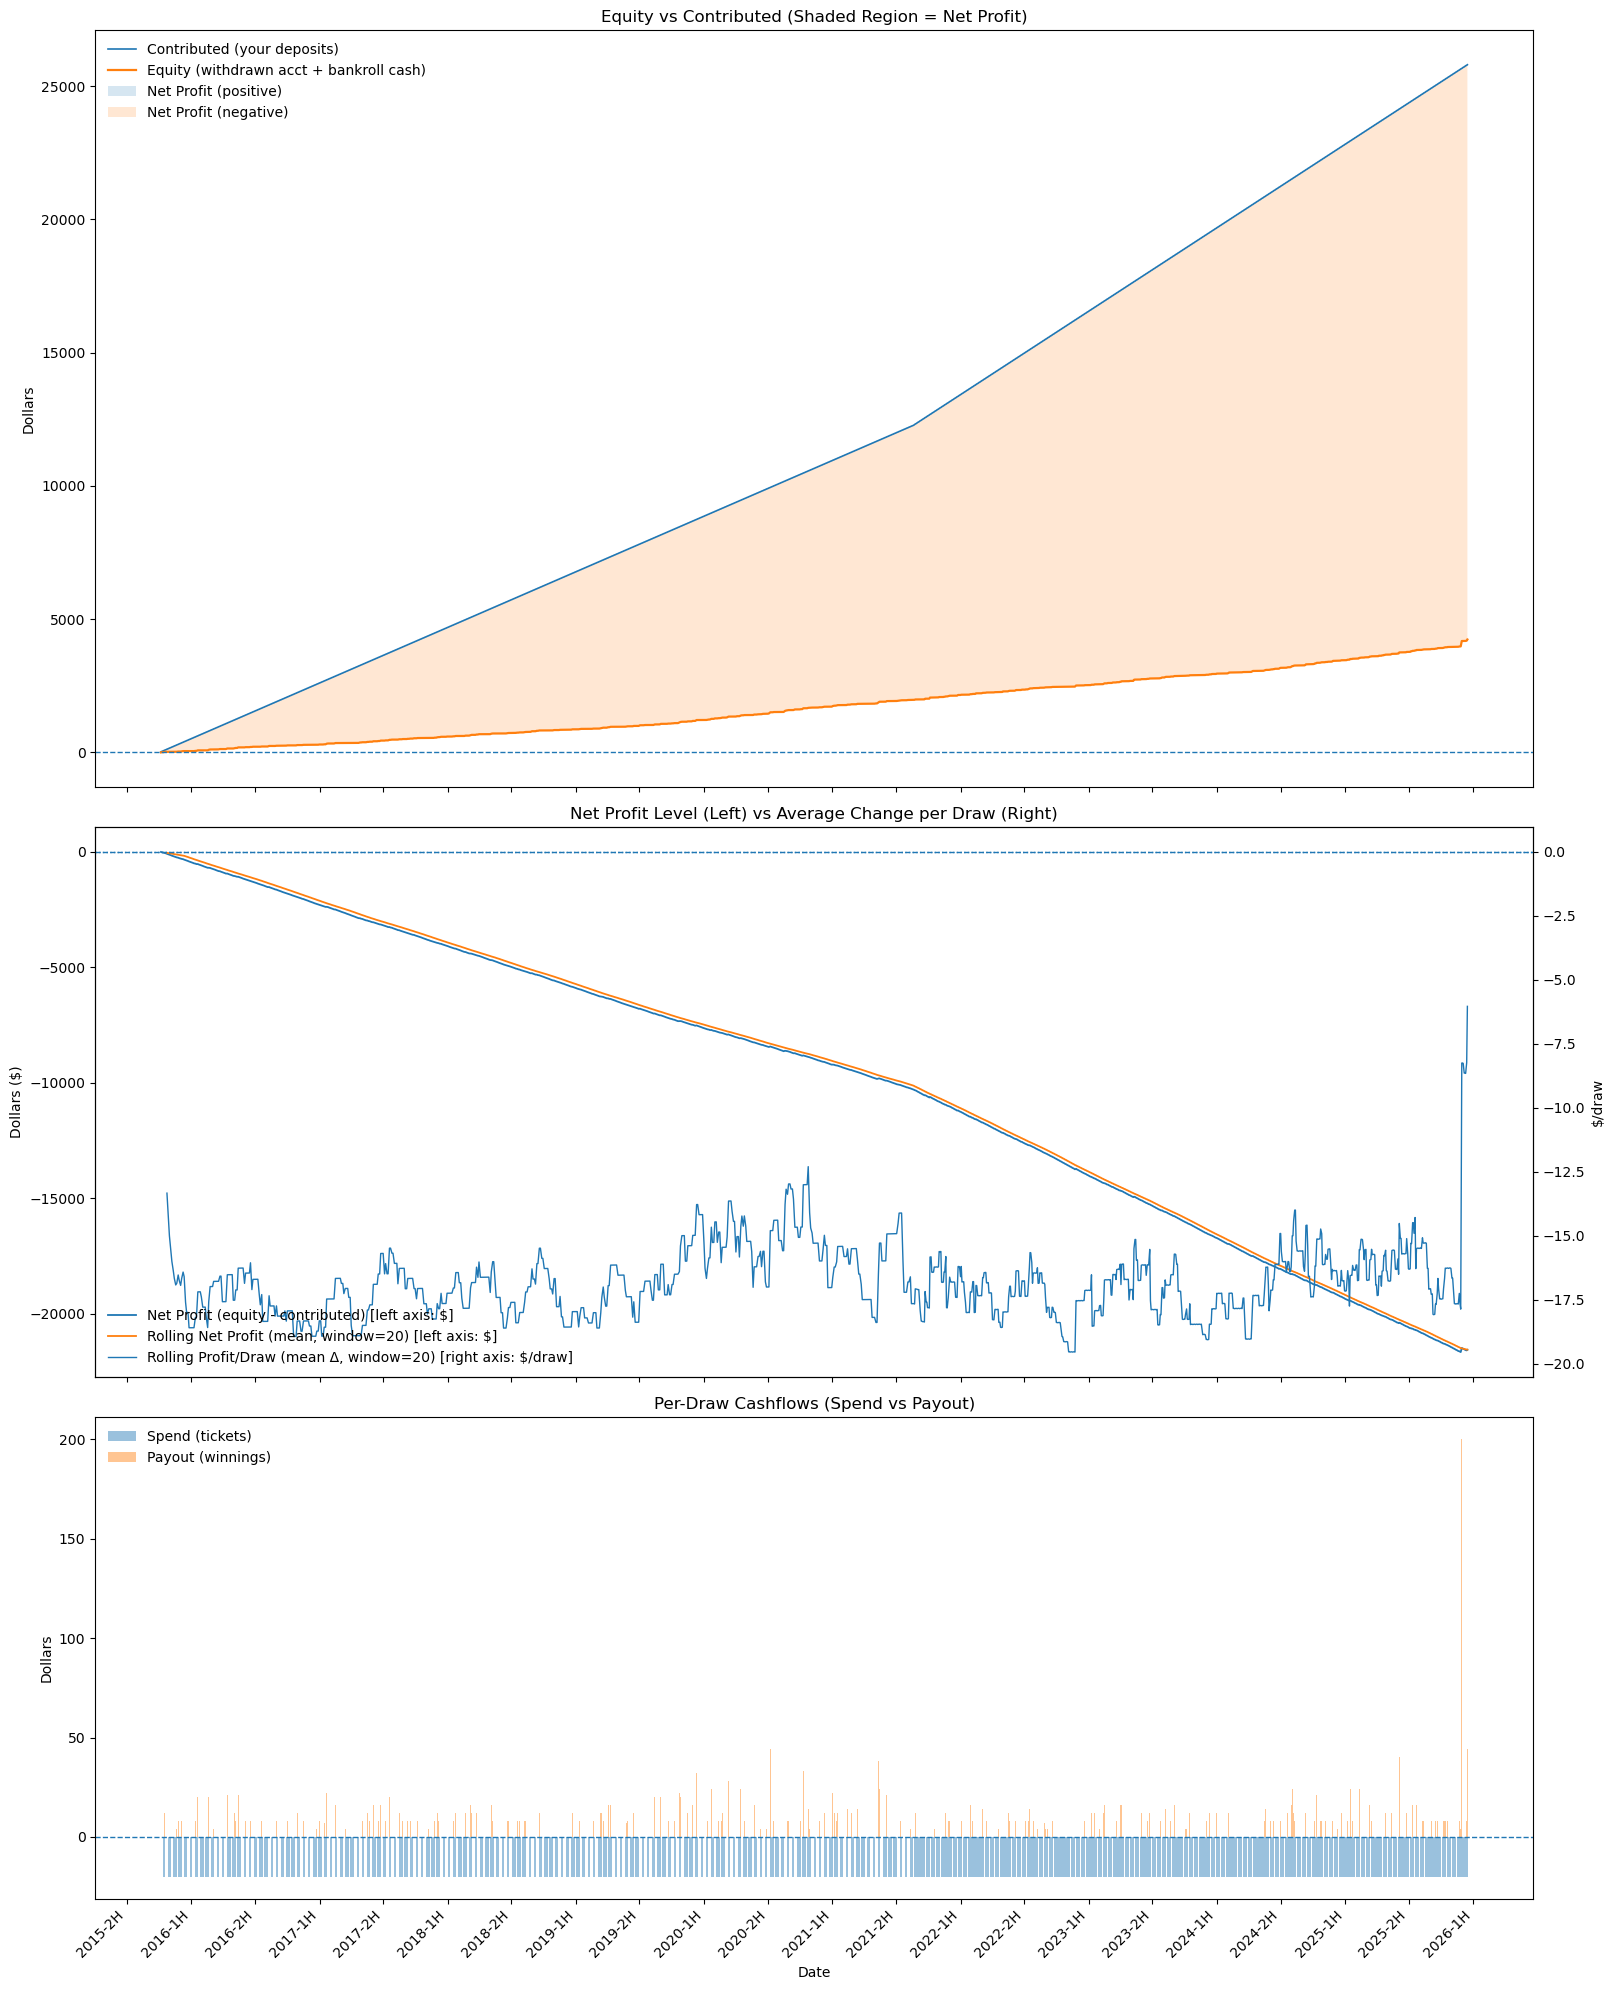

In [4]:
gen = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=20,
    use_multiplier=True,
    reinvest_percent=0.0,
    store_temperatures=True,
    rolling_window=20,
    prefer_numba=True,
    withdrawal_apy=0.03,
    max_T=100
)

out = bt.run(seed=None)
bt.plot_winnings(out)

In [5]:
bt.pnl_table 

,date,equity,net_profit,contributed,available,spend,draw_payout,withdrawn,withdrawn_balance,bankroll_cash
0,10/07/2015,0.000000,-20.000000,20.0,20.0,20.0,0.0,0.0,0.000000,0.0
1,10/10/2015,8.000000,-32.000000,40.0,20.0,20.0,8.0,8.0,8.000000,0.0
2,10/14/2015,8.002590,-51.997410,60.0,20.0,20.0,0.0,0.0,8.002590,0.0
3,10/17/2015,20.004533,-59.995467,80.0,20.0,20.0,12.0,12.0,20.004533,0.0
4,10/21/2015,20.011010,-79.988990,100.0,20.0,20.0,0.0,0.0,20.011010,0.0
...,...,...,...,...,...,...,...,...,...,...
1285,12/06/2025,4180.642259,-21539.357741,25720.0,20.0,20.0,0.0,0.0,4180.642259,0.0
1286,12/08/2025,4181.318972,-21558.681028,25740.0,20.0,20.0,0.0,0.0,4181.318972,0.0
1287,12/10/2025,4181.995795,-21578.004205,25760.0,20.0,20.0,0.0,0.0,4181.995795,0.0
1288,12/13/2025,4191.011235,-21588.988765,25780.0,20.0,20.0,8.0,8.0,4191.011235,0.0


### 2) Determinism/regression test harness (repeatability + RNG isolation)

In [ ]:
out1 = bt.run(seed=123456)
ticket1 = bt.last_ticket_detail.copy()

out2 = bt.run(seed=123456)
ticket2 = bt.last_ticket_detail.copy()

assert out1.equals(out2)
assert ticket1.equals(ticket2)
assert out1["net_profit"].iat[-1] == out2["net_profit"].iat[-1]  # scalar compare

### 3) Compare reinvestment policies (fixed_exposure vs nested_compounding)

In [ ]:
# Same ticket count each draw (isolates accounting effects)
df_fixed = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="fixed_exposure",
    plot=True,
)

# “Reinvest buys more tickets” while keeping runs comparable via nested pools
df_nested = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="nested_compounding",
    plot=True,
)

df_nested.head()

### 4) Model “withdraw winnings into an external account” (withdrawal_apy + draws_per_year)

In [ ]:
bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=100,
    reinvest_percent=0.50,   # half reinvest, half withdraw
    withdrawal_apy=0.05,     # external compounding on withdrawals
    draws_per_year=104,      # used to convert APY to per-draw rate
    max_T=200
)

out = bt.run(seed=7)
out

In [ ]:
bt.plot_winnings(out)

### 5) Plot a single run with dual-axis “net profit level vs profit/draw” and cashflows

In [ ]:
out = bt.run(seed=123)
bt.plot_winnings(out)
# optional:
ticket_df = bt.last_ticket_detail
summary = bt.last_summary

### 6) Temperature-stratified performance (deciles of white temperature)

In [ ]:
draw_detail = bt.run(seed=123)  # run() returns draw_detail now :contentReference[oaicite:1]{index=1}
ticket_detail = bt.last_ticket_detail  # populated by run() :contentReference[oaicite:2]{index=2}

summary = bt.summarize_by_white_temperature_deciles(ticket_detail, q=10)
summary

### 7) Performance run: turn off metadata to reduce overhead (store_temperatures=False)

In [ ]:
bt_fast = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=500,
    store_temperatures=False,  # leaner generation; no temp columns
    prefer_numba=True,
)

draw_detail = bt_fast.run(seed=123)  # returns draw_detail :contentReference[oaicite:3]{index=3}
ticket_detail = bt_fast.last_ticket_detail  # populated by run() :contentReference[oaicite:4]{index=4}

print(ticket_detail.columns)  # should not include white_temperature/red_temperature

### 8) Verify multiplier economics and budget allocation behavior

In [ ]:
bt_alloc = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=7,
    use_multiplier=True,
)

# Internal allocation logic: (n_multiplier, n_non_multiplier)
print(bt_alloc._allocate_ticket_counts(7))   # expected pattern like (1, 2)
print(bt_alloc._allocate_ticket_counts(10))  # expected pattern like (2, 2)

### 9) Enforced uniqueness across multiplier and non-multiplier pools (per draw)

In [ ]:
bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,            # must support existing_tickets=...
    ticket_budget=101,
    use_multiplier=True,
)

draw_detail = bt.run(seed=99)          # returns draw_detail :contentReference[oaicite:5]{index=5}
td = bt.last_ticket_detail             # ticket-level rows :contentReference[oaicite:6]{index=6}

dupes = td.duplicated(
    subset=["date", "white_1", "white_2", "white_3", "white_4", "white_5", "red_ball"]
).sum()

print("duplicate tickets within a draw:", dupes)

### 10) Use the generator standalone (CSV-friendly ticket export + uniqueness controls)

In [ ]:
gen = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

# Cashier-friendly output (flat columns)
tickets = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=False,
    ensure_unique=True,
)

# Export-ready
df = pd.DataFrame(tickets)
df.to_csv("tickets.csv", index=False)

# Enforce uniqueness vs an existing pool (e.g., “don’t repeat last week’s tickets”)
more = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=True,
    ensure_unique=True,
    existing_tickets=tickets,
)

df

In [ ]:
pd.DataFrame(more)

In [ ]:
import numpy as np
import pandas as pd

from powerball_backtester import PowerballBacktester
from powerball_ml_ticket_generator import PowerballMLTicketGenerator  # wherever you saved the class
from scipy.stats import randint, loguniform

'''
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Unit time (1 head, 1 ensemble member, full search): 281.3 seconds
Estimated total (upper bound, red ~= white): 4.22 hours
Estimated total (red ~ 0.5 * white):         3.87 hours

With mc_strategy="repeated_random_search" multipy by 33.5 for 40 n_iter
With mc_strategy="repeated_random_search" multipy by 16.8 for 20 n_iter
'''

param_space = {
    # More conservative; avoids aggressive fitting.
    "model__learning_rate": loguniform(0.02, 0.06),

    # Lower capacity; discourages memorization of lag-feature quirks.
    "model__max_leaf_nodes": randint(8, 41),          # [8..40]

    # Stronger smoothing (crucial for the red head).
    "model__min_samples_leaf": randint(40, 251),      # [40..250]

    # Push regularization up; noise-fitting becomes expensive.
    "model__l2_regularization": loguniform(1e-3, 10.0),

    # Keep trees shallow; drop None to avoid “free depth”.
    "model__max_depth": [2, 3, 4],

    # Coarser hist bins; fewer split candidates.
    "model__max_bins": randint(64, 129),              # [64..128]
}

ml = PowerballMLTicketGenerator(
    draw_data="powerball.csv",
    lag_n=3,
    rolling_windows=(5, 10, 15),
    augment_permutations=0,
    use_quantile=False,                 # OFF for boosting
    enable_tuning=True,
    mc_ensemble_size=9,                 # must be >= max ensemble_size you want to test later
    mc_strategy="repeated_random_search",
    tuning_n_iter=15,
    tuning_cv_splits=5,                 # TimeSeriesSplit on train only
    param_distributions=param_space,
    seed=123,
    verbose=True,
).fit()

print(ml.evaluate(split="val"))

# Save without embedding draws (smaller artifact)
ml.save_state("boosted_trees_no_perm_powerball.joblib", include_draws=False)

In [ ]:
from powerball_backtester import PowerballBacktester
from powerball_ml_ticket_generator import PowerballMLTicketGenerator  # wherever you saved the class

# Later: load and provide draw_data
ml = PowerballMLTicketGenerator.load_state(
    "boosted_trees_with_perm_powerball.joblib",
    draw_data="powerball.csv",
)

tickets = ml.generate_tickets(n=20, temperature=1.0, as_flat=True)
print(tickets[0])

In [ ]:
from powerball_ml_ticket_generator import PowerballMLTicketGenerator
from powerball_ml_policy import MLBacktesterGenerator
from powerball_backtester import PowerballBacktester

ml = PowerballMLTicketGenerator.load_state(
    "boosted_trees_with_perm_powerball.joblib",
    draw_data="powerball.csv",
)

gen = MLBacktesterGenerator(
    ml=ml,
    temperature=1.0,
    ensemble_size=1,
    seed=123
)

bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=3,
    use_multiplier=True,
    reinvest_percent=0.0
)
out = bt.run()
bt.plot_winnings(out)

In [ ]:
bt.last_summary

In [ ]:
bt.last_ticket_detail.iloc[-100:]

In [ ]:
n = len(ml.draws) - 1
n_test = max(1, int(round(n * ml.test_size)))
n_val  = max(1, int(round(n * ml.val_size)))
n_train = n - n_val - n_test

val_start = n_train + 1
val_end   = n_train + n_val
pnl_val = out.iloc[val_start:val_end+1]
print("VAL window net:", (pnl_val["draw_payout"] - pnl_val["spend"]).sum())
print("VAL window max draw_payout:", pnl_val["draw_payout"].max())

In [ ]:
out.iloc[val_start:val_end+1]

In [ ]:
bt.plot_winnings(pnl_val)

In [ ]:
# from powerball_ml_policy import policy_search_on_val, MLBacktesterGenerator
# from powerball_backtester import PowerballBacktester

# # 1) pick policy on val
# best_policy, policy_df = policy_search_on_val(
#     ml,
#     draw_csv="powerball.csv",
#     jackpot_csv="jackpots.csv",
#     ticket_budget=20,
#     use_multiplier=False,
# )

# T_star = float(best_policy["temperature"])
# M_star = int(best_policy["ensemble_size"])

# # 2) run backtest using chosen policy
# gen_star = MLBacktesterGenerator(ml, temperature=T_star, ensemble_size=M_star, seed=123)

# bt = PowerballBacktester(
#     draw_csv="powerball.csv",
#     jackpot_csv="jackpots.csv",
#     generator=gen_star,
#     ticket_budget=20,
#     use_multiplier=False,
#     reinvest_percent=0.0,
#     store_temperatures=True,
#     seed=123,
# )

# pnl = bt.run(seed=123)  # run() returns a draw-level DataFrame and sets bt.last_ticket_detail :contentReference[oaicite:3]{index=3}
# ticket_detail = bt.last_ticket_detail

# print(pnl.tail())
# print("Final net_profit:", float(pnl["net_profit"].iloc[-1]))
# print("Ticket rows:", ticket_detail.shape)

# # 3) TEST-window incremental profit
# n_train = len(ml.splits_.X_train)
# n_val = len(ml.splits_.X_val)
# n_test = len(ml.splits_.X_test)

# test_start = (n_train + n_val) + 1
# test_end = (n_train + n_val + n_test)

# pnl_test = pnl.iloc[test_start:test_end + 1]
# test_profit = float((pnl_test["draw_payout"] - pnl_test["spend"]).sum())
# print("Incremental profit over TEST window:", test_profit)